In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_style('whitegrid')
%matplotlib inline

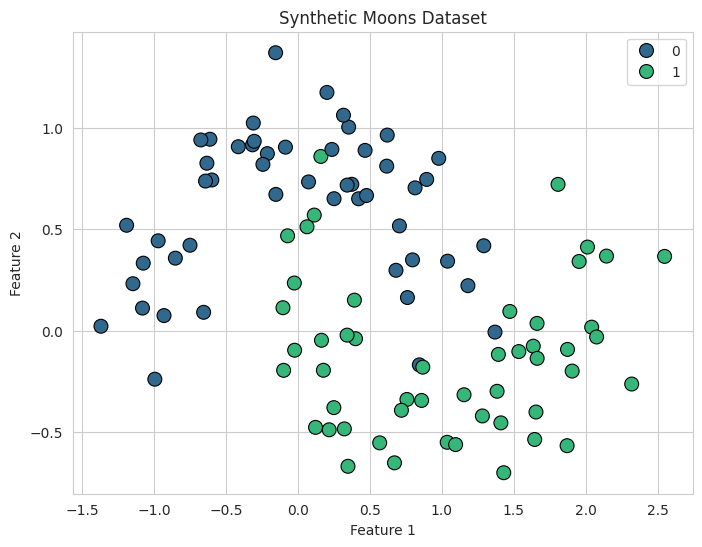

In [15]:
X, y = make_moons(n_samples=100, noise=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, marker='o', s=100, edgecolor='k', palette='viridis')
plt.title('Synthetic Moons Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [3]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, marker='o', s=100, edgecolor='k', palette='viridis')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

Underfit Decision Tree Training Accuracy: 0.8429
Underfit Decision Tree Test Accuracy: 0.8000


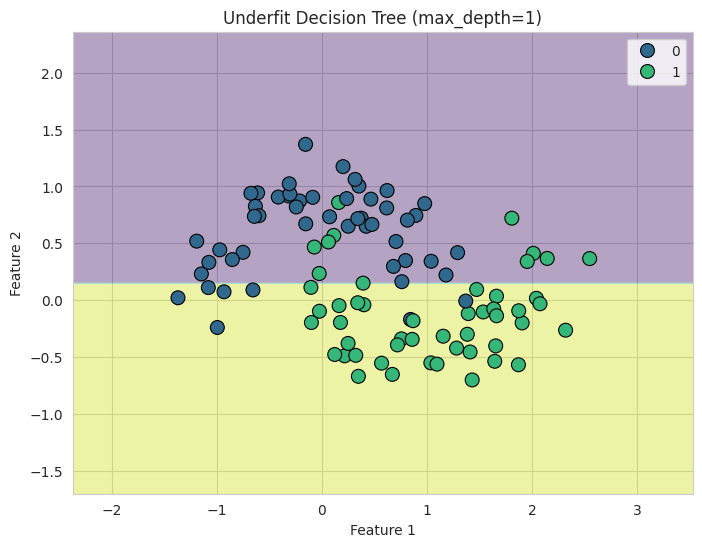

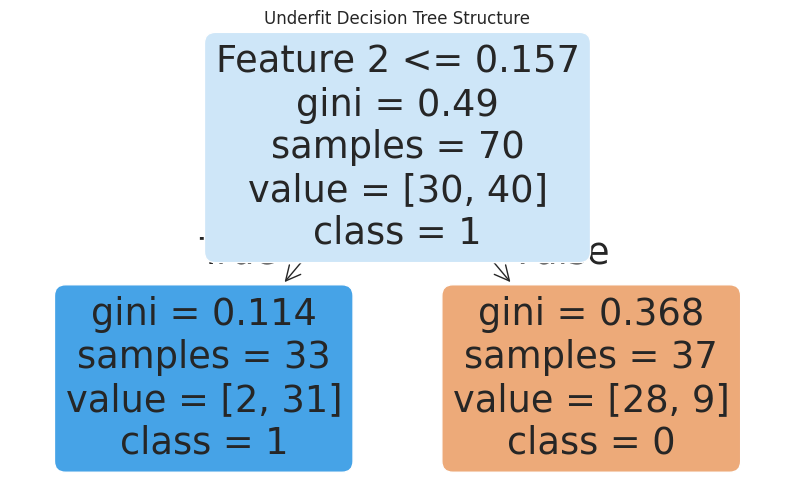

In [16]:
dt_underfit = DecisionTreeClassifier(max_depth=1, random_state=42)
dt_underfit.fit(X_train, y_train)

y_pred_underfit = dt_underfit.predict(X_test)
print(f'Underfit Decision Tree Training Accuracy: {accuracy_score(y_train, dt_underfit.predict(X_train)):.4f}')
print(f'Underfit Decision Tree Test Accuracy: {accuracy_score(y_test, y_pred_underfit):.4f}')

plot_decision_boundary(dt_underfit, X, y, 'Underfit Decision Tree (max_depth=1)')

plt.figure(figsize=(10, 6))
plot_tree(dt_underfit, filled=True, feature_names=['Feature 1', 'Feature 2'], class_names=['0', '1'], rounded=True)
plt.title('Underfit Decision Tree Structure')
plt.show()

Overfit Decision Tree Training Accuracy: 1.0000
Overfit Decision Tree Test Accuracy: 0.8667


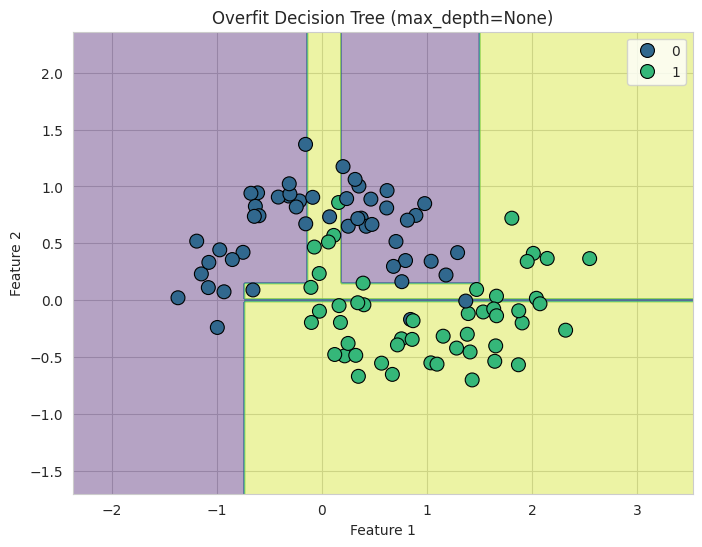

In [17]:
dt_overfit = DecisionTreeClassifier(random_state=42)
dt_overfit.fit(X_train, y_train)

y_pred_overfit = dt_overfit.predict(X_test)
print(f'Overfit Decision Tree Training Accuracy: {accuracy_score(y_train, dt_overfit.predict(X_train)):.4f}')
print(f'Overfit Decision Tree Test Accuracy: {accuracy_score(y_test, y_pred_overfit):.4f}')

plot_decision_boundary(dt_overfit, X, y, 'Overfit Decision Tree (max_depth=None)')

Tuned Decision Tree Training Accuracy: 0.9143
Tuned Decision Tree Test Accuracy: 0.9333


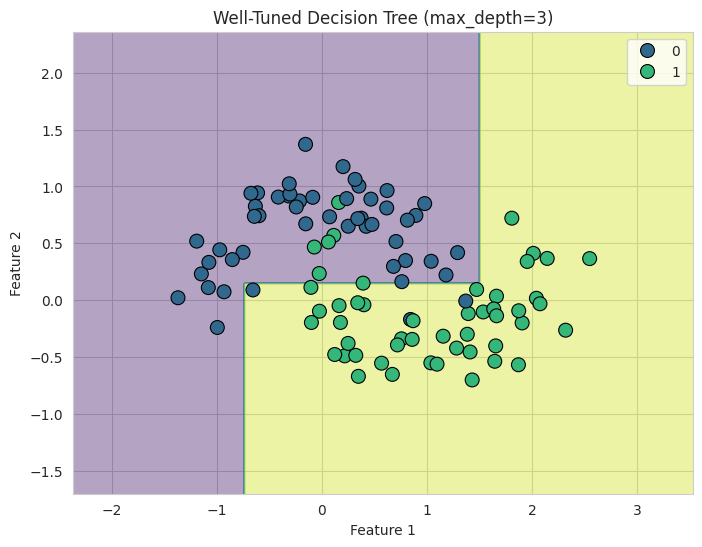

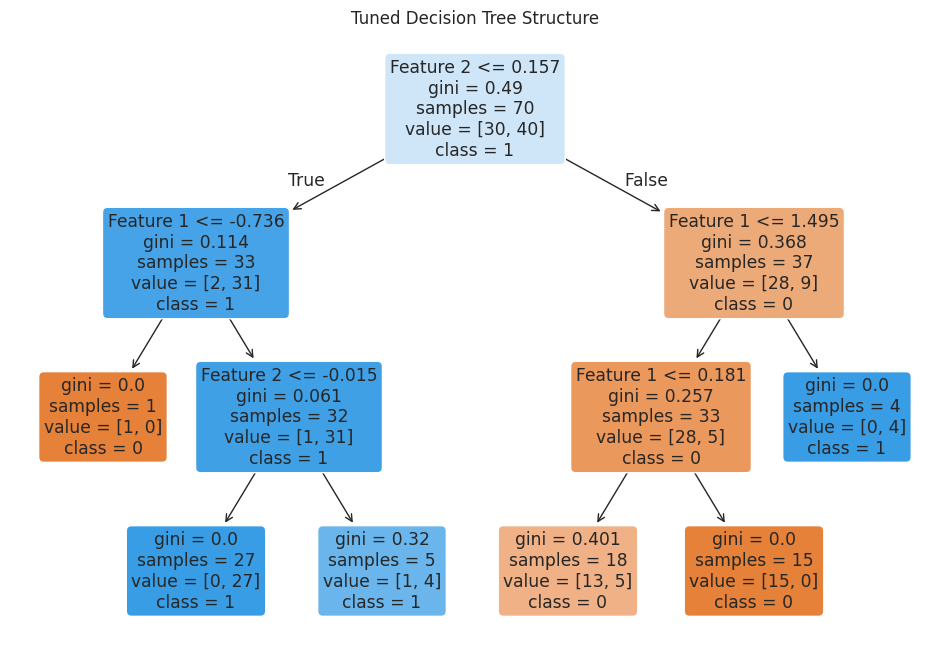

In [18]:
dt_tuned = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_tuned.fit(X_train, y_train)

y_pred_tuned = dt_tuned.predict(X_test)
print(f'Tuned Decision Tree Training Accuracy: {accuracy_score(y_train, dt_tuned.predict(X_train)):.4f}')
print(f'Tuned Decision Tree Test Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}')

plot_decision_boundary(dt_tuned, X, y, 'Well-Tuned Decision Tree (max_depth=3)')

plt.figure(figsize=(12, 8))
plot_tree(dt_tuned, filled=True, feature_names=['Feature 1', 'Feature 2'], class_names=['0', '1'], rounded=True)
plt.title('Tuned Decision Tree Structure')
plt.show()

Naïve Bayes Training Accuracy: 0.8571
Naïve Bayes Test Accuracy: 0.8667


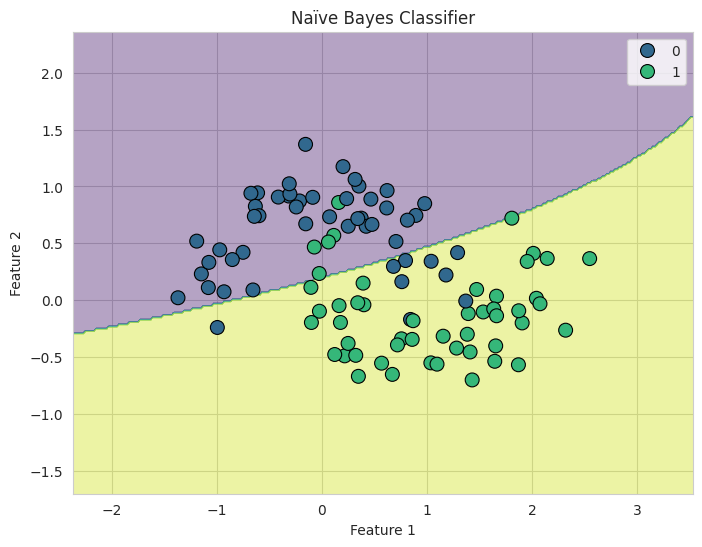

In [19]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
print(f'Naïve Bayes Training Accuracy: {accuracy_score(y_train, nb_model.predict(X_train)):.4f}')
print(f'Naïve Bayes Test Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}')

plot_decision_boundary(nb_model, X, y, 'Naïve Bayes Classifier')

In [20]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_underfit = cross_val_score(dt_underfit, X, y, cv=kf, scoring='accuracy')
print(f'Underfit Decision Tree CV Accuracy: {cv_scores_underfit.mean():.4f} (+/- {cv_scores_underfit.std() * 2:.4f})')

cv_scores_overfit = cross_val_score(dt_overfit, X, y, cv=kf, scoring='accuracy')
print(f'Overfit Decision Tree CV Accuracy: {cv_scores_overfit.mean():.4f} (+/- {cv_scores_overfit.std() * 2:.4f})')

cv_scores_tuned = cross_val_score(dt_tuned, X, y, cv=kf, scoring='accuracy')
print(f'Tuned Decision Tree CV Accuracy: {cv_scores_tuned.mean():.4f} (+/- {cv_scores_tuned.std() * 2:.4f})')

cv_scores_nb = cross_val_score(nb_model, X, y, cv=kf, scoring='accuracy')
print(f'Naïve Bayes CV Accuracy: {cv_scores_nb.mean():.4f} (+/- {cv_scores_nb.std() * 2:.4f})')

Underfit Decision Tree CV Accuracy: 0.7900 (+/- 0.0980)
Overfit Decision Tree CV Accuracy: 0.8900 (+/- 0.1166)
Tuned Decision Tree CV Accuracy: 0.8900 (+/- 0.1470)
Naïve Bayes CV Accuracy: 0.8400 (+/- 0.2135)


Best max_depth: 2
Best cross-validation accuracy: 0.8900
Best Model Test Accuracy: 0.9667


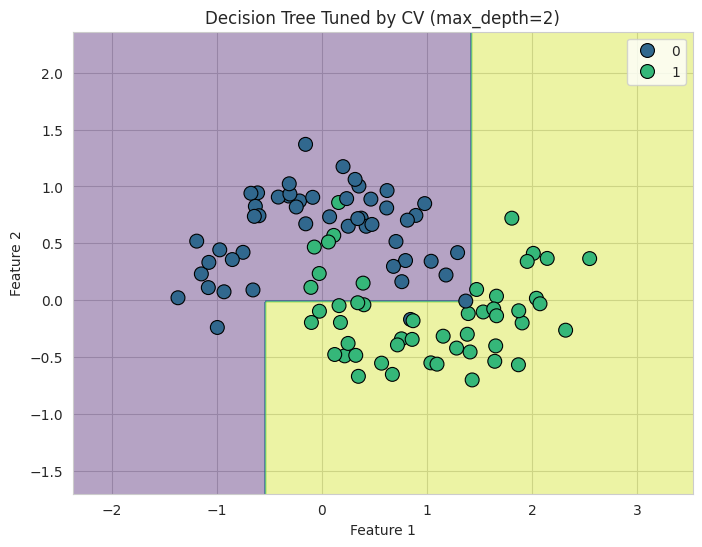

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth': range(1, 10)}

dt_base = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(dt_base, param_grid, cv=kf, scoring='accuracy', n_jobs=-1)
grid_search.fit(X, y)

print(f'Best max_depth: {grid_search.best_params_["max_depth"]}')
print(f'Best cross-validation accuracy: {grid_search.best_score_:.4f}')

best_dt_model = grid_search.best_estimator_

y_pred_best = best_dt_model.predict(X_test)
print(f'Best Model Test Accuracy: {accuracy_score(y_test, y_pred_best):.4f}')

plot_decision_boundary(best_dt_model, X, y, f'Decision Tree Tuned by CV (max_depth={grid_search.best_params_["max_depth"]})')